# 🩸 Couche 2 — Exploration des données (Démographie & Épidémiologie)

**Objectif :** collecter → cleaner → **fusionner** des données réelles (World Bank / FAO) en
un seul dataset keyé sur `(Pays, Année)`, puis l'explorer.

- Collecte : `python couche2/download_data.py` → `data/couche2/*.csv`
- Nettoyage + fusion : `python couche2/clean_merge.py` → `data/couche2/dataset_couche2.csv`
- Sources détaillées : `couche2/SOURCES_DONNEES.txt`

Ici on charge le dataset fusionné et on répond à : **est-il exploitable ? que raconte-t-il ?**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid'); sns.set_palette('Set2')
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.titleweight': 'bold'})

# Trouve le dataset que l'on soit à la racine ou dans couche2/
DATA = next(p for p in ('data/couche2', '../data/couche2')
            if os.path.exists(os.path.join(p, 'dataset_couche2.csv')))
df = pd.read_csv(os.path.join(DATA, 'dataset_couche2.csv'))
print('Dataset fusionné :', df.shape, '|', df['Pays'].nunique(), 'pays |',
      int(df['Annee'].min()), '-', int(df['Annee'].max()))
df.head()

Dataset fusionné : (14322, 13) | 217 pays | 1960 - 2025


,Code_Pays,Pays,Region,Annee,Natalite_pour1000,Fecondite_enf_par_femme,MortInfantile_pour1000,MortMoins5ans_pour1000,MortBrute_pour1000,Densite_hab_km2,Population,Carence_pct,MigrationNette
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",1960,50.516,7.282,252.4,350.6,31.672,NaN,9035043.0,NaN,2606
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",1961,50.566,7.284,249.2,345.2,31.129,14.127046,9214083.0,NaN,6109
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",1962,50.666,7.292,246.4,340.2,30.630,14.418849,9404406.0,NaN,7016
3,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",1963,50.787,7.302,243.6,335.0,30.168,14.725614,9604487.0,NaN,6681
4,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",1964,50.852,7.304,240.6,329.7,29.672,15.047327,9814318.0,NaN,7079


## 1. Complétude — la fusion est-elle exploitable ?

On regarde le **taux de remplissage** de chaque indicateur, et son **évolution dans le temps**
(les données récentes sont plus complètes ; la carence FAO ne commence qu'en 2001).

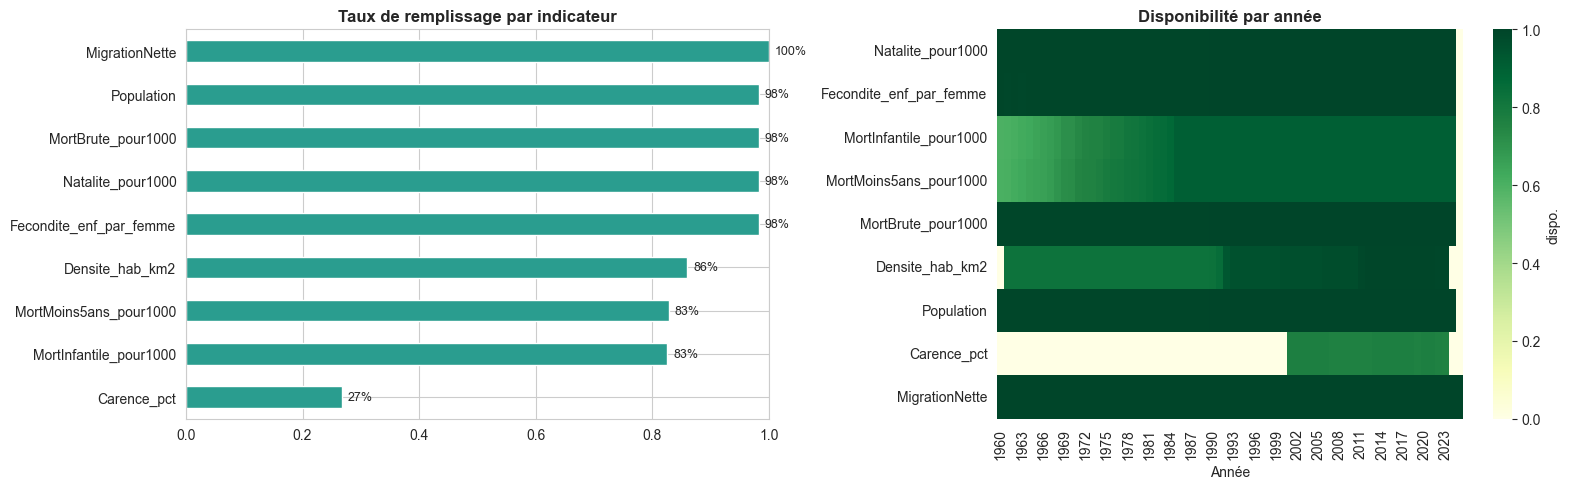

In [2]:
indics = ['Natalite_pour1000','Fecondite_enf_par_femme','MortInfantile_pour1000',
          'MortMoins5ans_pour1000','MortBrute_pour1000','Densite_hab_km2',
          'Population','Carence_pct','MigrationNette']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Taux de remplissage global
compl = df[indics].notna().mean().sort_values()
compl.plot(kind='barh', ax=ax1, color='#2a9d8f')
ax1.set_title('Taux de remplissage par indicateur'); ax1.set_xlim(0, 1)
for i, v in enumerate(compl.values):
    ax1.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)

# Disponibilité par année (heatmap)
dispo = df.groupby('Annee')[indics].apply(lambda g: g.notna().mean())
sns.heatmap(dispo.T, cmap='YlGn', vmin=0, vmax=1, ax=ax2, cbar_kws={'label': 'dispo.'})
ax2.set_title('Disponibilité par année'); ax2.set_xlabel('Année'); ax2.set_ylabel('')
plt.tight_layout(); plt.show()

## 2. Distributions des indicateurs démographiques

Forme de chaque variable (asymétries, valeurs typiques).

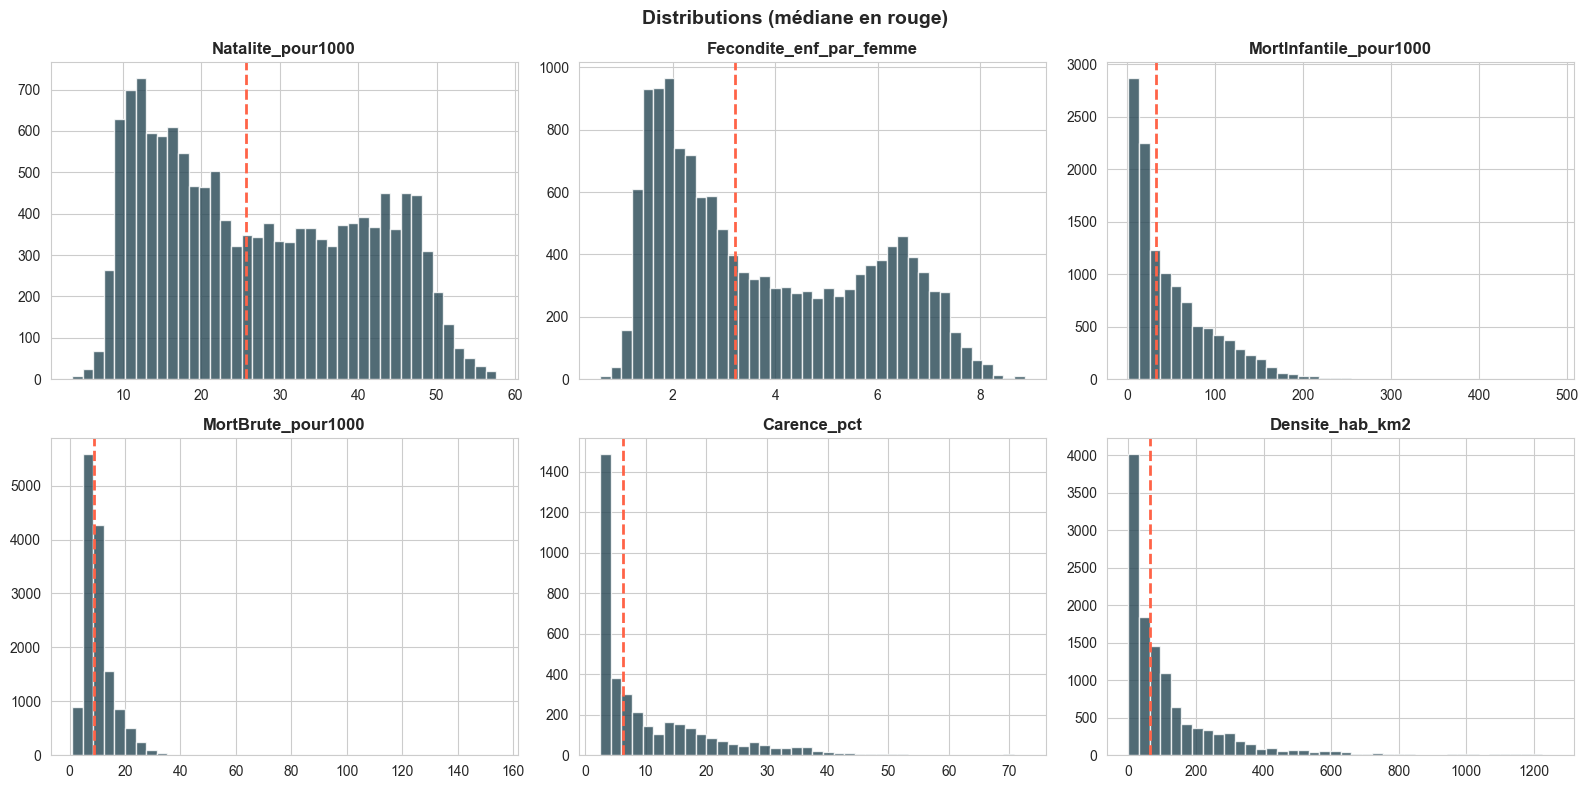

In [3]:
cols = ['Natalite_pour1000','Fecondite_enf_par_femme','MortInfantile_pour1000',
        'MortBrute_pour1000','Carence_pct','Densite_hab_km2']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cols):
    d = df[c].dropna()
    if c == 'Densite_hab_km2':
        d = d[d < d.quantile(0.97)]   # on coupe les outliers extrêmes pour la lisibilité
    ax.hist(d, bins=40, color='#264653', alpha=0.8, edgecolor='white')
    ax.set_title(c); ax.axvline(d.median(), color='tomato', ls='--', lw=2)
fig.suptitle('Distributions (médiane en rouge)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Évolution mondiale dans le temps — la transition démographique

**Hypothèse :** depuis 1960, la fécondité et la mortalité infantile **baissent** mondialement.

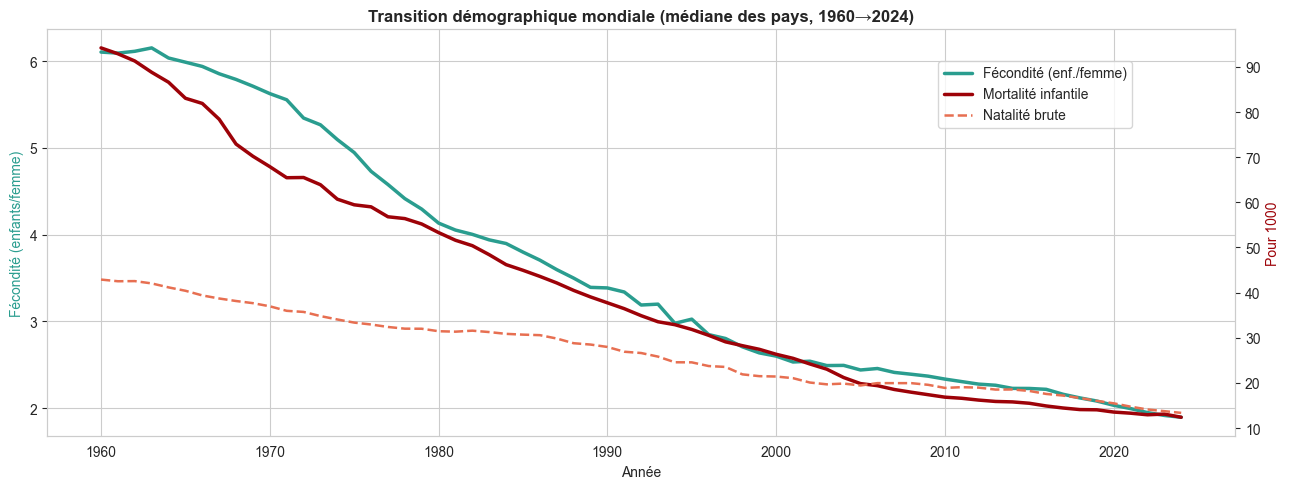

In [4]:
eta = df.groupby('Annee')[['Fecondite_enf_par_femme','MortInfantile_pour1000',
                           'Natalite_pour1000']].median()
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(eta.index, eta['Fecondite_enf_par_femme'], color='#2a9d8f', lw=2.5, label='Fécondité (enf./femme)')
ax1.set_ylabel('Fécondité (enfants/femme)', color='#2a9d8f'); ax1.set_xlabel('Année')
ax2 = ax1.twinx()
ax2.plot(eta.index, eta['MortInfantile_pour1000'], color='#9d0208', lw=2.5, label='Mortalité infantile')
ax2.plot(eta.index, eta['Natalite_pour1000'], color='#e76f51', lw=1.8, ls='--', label='Natalité brute')
ax2.set_ylabel('Pour 1000', color='#9d0208'); ax2.grid(False)
ax1.set_title('Transition démographique mondiale (médiane des pays, 1960→2024)')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88)); plt.tight_layout(); plt.show()

## 4. Corrélations entre indicateurs

**Hypothèse :** mortalité infantile, fécondité et carence sont fortement liées (pays pauvres).

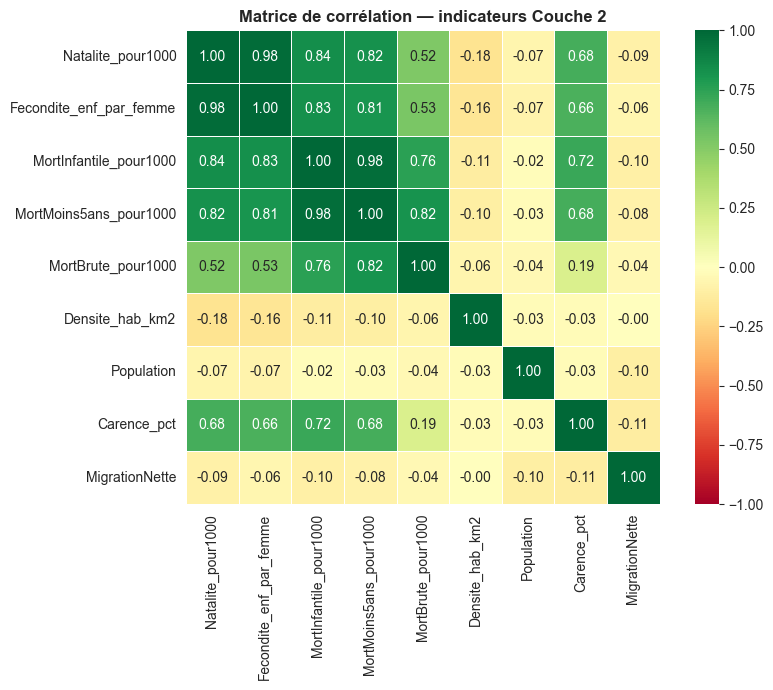

In [5]:
corr = df[indics].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax)
ax.set_title('Matrice de corrélation — indicateurs Couche 2'); plt.tight_layout(); plt.show()

## 5. Relation clé : Fécondité ↔ Mortalité infantile (par région)

Le couple emblématique de la transition démographique, sur les données récentes (2015+).

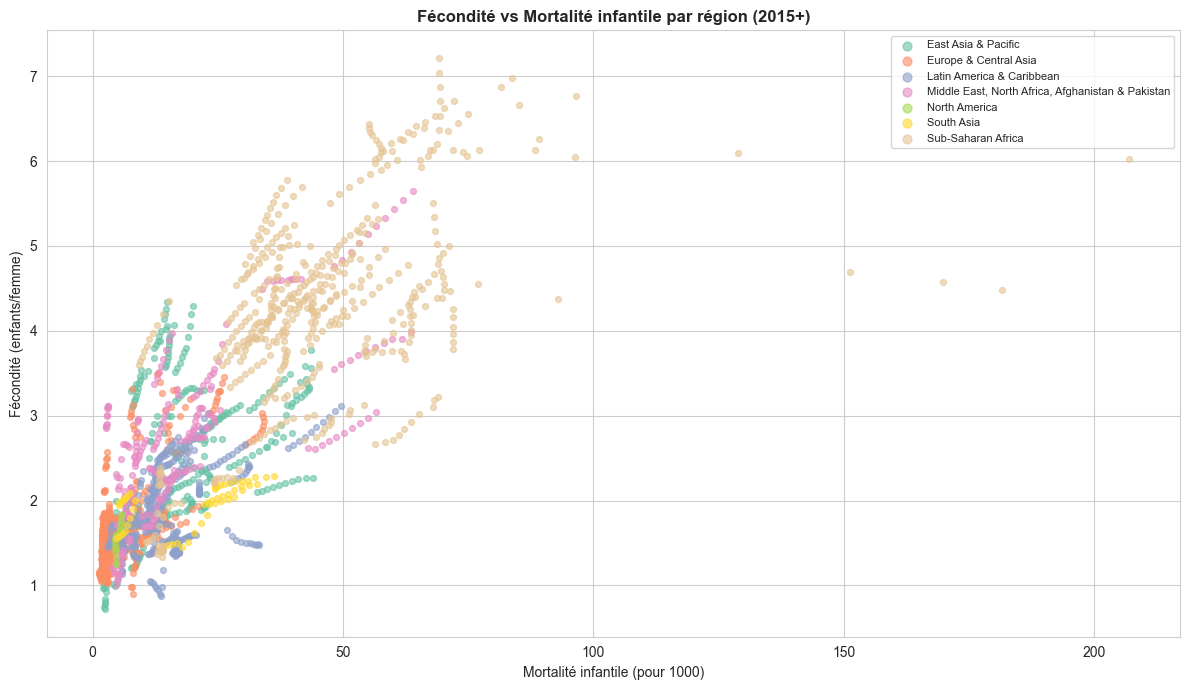

Corrélation Fécondité × Mortalité infantile : 0.806


In [6]:
recent = df[df['Annee'] >= 2015].dropna(subset=['Fecondite_enf_par_femme','MortInfantile_pour1000'])
fig, ax = plt.subplots(figsize=(12, 7))
for region, g in recent.groupby('Region'):
    ax.scatter(g['MortInfantile_pour1000'], g['Fecondite_enf_par_femme'],
               s=18, alpha=0.6, label=region)
ax.set_xlabel('Mortalité infantile (pour 1000)'); ax.set_ylabel('Fécondité (enfants/femme)')
ax.set_title('Fécondité vs Mortalité infantile par région (2015+)')
ax.legend(fontsize=8, markerscale=1.5); plt.tight_layout(); plt.show()
print('Corrélation Fécondité × Mortalité infantile :',
      round(recent['Fecondite_enf_par_femme'].corr(recent['MortInfantile_pour1000']), 3))

## 6. ✍️ Conclusions

1. **La fusion fonctionne** : 9 indicateurs World Bank/FAO se joignent proprement sur
   `(Pays, Année)` → un dataset unique de ~14 000 lignes, 217 pays, 1960→2024.
2. **Exploitable**, avec deux réserves de complétude :
   - `Carence_pct` (FAO) ne commence qu'en **2001** (~27 % de remplissage global).
   - Mortalité par âge : ~83 % (petits pays manquants).
3. **Signal fort** : transition démographique nette (fécondité ↓, mortalité infantile ↓) et
   forte corrélation positive fécondité ↔ mortalité infantile ↔ carence.
4. **Project Tycho (épidémies)** ne se fusionne pas (état US / semaine) → dataset séparé
   à analyser à part pour le volet épidémiologique.

➡️ **Dataset final prêt :** `data/couche2/dataset_couche2.csv`